In [54]:
# install important libraries
!pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from statsmodels.graphics.tsaplots import plot_acf

Shape: (4032, 1)
                      value
timestamp                  
2014-03-07 03:41:00  45.868
2014-03-07 03:46:00  47.606
2014-03-07 03:51:00  42.580
2014-03-07 03:56:00  46.030
2014-03-07 04:01:00  44.992


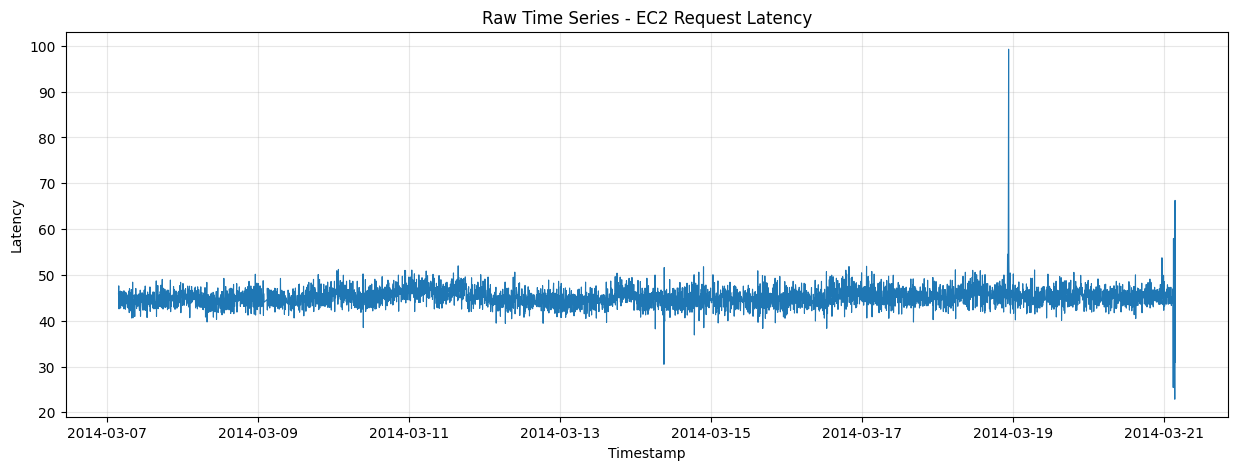

In [56]:
# Load data
df = pd.read_csv('ec2_request_latency_system_failure.csv', 
                 parse_dates=['timestamp'], 
                 index_col='timestamp')
print(f"Shape: {df.shape}")
print(df.head())
# Plot raw time series
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'], linewidth=0.8)
plt.title('Raw Time Series - EC2 Request Latency')
plt.xlabel('Timestamp')
plt.ylabel('Latency')
plt.grid(True, alpha=0.3)
plt.show()


In [57]:
# Calculate basic statistics: mean, std, skewness, min, max
values = df['value']

mean_val = values.mean()
std_val = values.std()
skewness = skew(values)
min_val = values.min()
max_val = values.max()

print("BASIC STATISTICS:")
print(f"Mean:     {mean_val:.4f}")
print(f"Std:      {std_val:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Min:      {min_val:.4f}")
print(f"Max:      {max_val:.4f}")


BASIC STATISTICS:
Mean:     45.1559
Std:      2.2871
Skewness: 3.0619
Min:      22.8640
Max:      99.2480


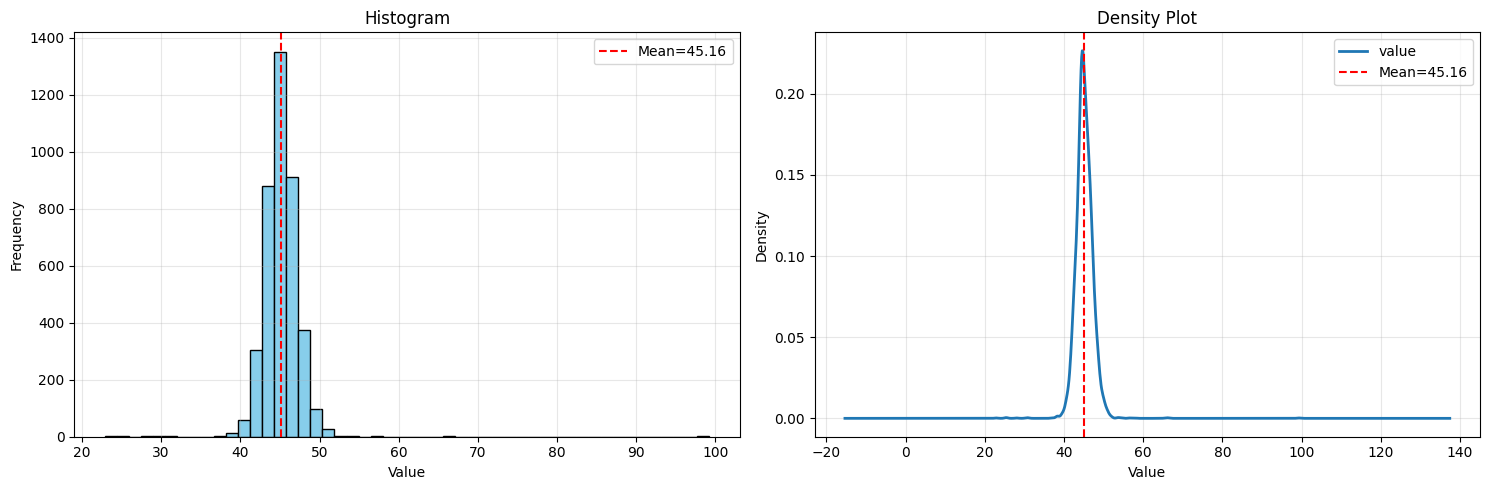


gaussian check:
Skewness = 3.0619 → Data is skewed 


In [58]:
# Plot histogram + density
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(values, bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.2f}')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Density
values.plot(kind='kde', ax=axes[1], linewidth=2)
axes[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.2f}')
axes[1].set_title('Density Plot')
axes[1].set_xlabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check Gaussian
print("\ngaussian check:")
if abs(skewness) < 0.5:
    print(f"Skewness = {skewness:.4f} → Data is approximately gaussian")
else:
    print(f"Skewness = {skewness:.4f} → Data is skewed ")

<Figure size 1500x500 with 0 Axes>

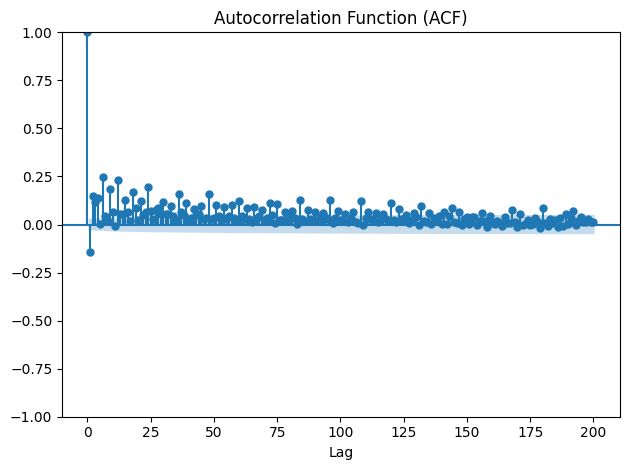


seasonal check:
Seasonal pattern detected!
Main period: 5 lags (~0.4 hours)


In [59]:
# Plot ACF - Check seasonality
plt.figure(figsize=(15, 5))
plot_acf(values, lags=200)
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.tight_layout()
plt.show()

# Detect peaks in ACF
from scipy.signal import find_peaks
acf_vals = [values.autocorr(lag=i) for i in range(1, 201)]
peaks, _ = find_peaks(acf_vals, height=0.1, distance=10)

print("\nseasonal check:")
if len(peaks) > 0:
    print(f"Seasonal pattern detected!")
    print(f"Main period: {peaks[0]} lags (~{peaks[0]*5/60:.1f} hours)")
else:
    print("no seasonal pattern")

# Phase 1: EDA - Kết Luận và Lựa Chọn Phương Pháp

##  Kết Quả Phân Tích

### Basic Statistics
- Mean: 45.1559
- Std: 2.2871
- Skewness: 3.0619 (heavily right-skewed)
- Min: 22.8640
- Max: 99.2480

### Đặc Điểm Data

#### 1. **Skewness (Độ lệch)**
- Skewness = 3.0619 → Data bị lệch nặng về phía bên phải
- Có nhiều outliers ở phía bên phải (giá trị cao bất thường)
- Mean (45.16) > Median (do skewed) → có spike/anomaly kéo mean lên cao

**Ý nghĩa**: 
- Data không tuân theo phân phối chuẩn
- Latency cao thất thường
- Phương pháp dựa trên Gaussian (Z-score) sẽ ko dùng được

---

#### 2. **Seasonality (Tính mùa vụ)**
- Main period: 5 lags (~0.4 hours = 25 minutes)
- Data có chu kỳ lặp lại ngắn

**Ý nghĩa**:
- Data có pattern lặp lại theo thời gian
- Cần phương pháp có khả năng tách seasonal component
- STL decomposition sẽ dùng được trong case này

---

#### 3. **Stationarity (Tính dừng)**
- Cần kiểm tra rolling mean/std để xác định
- Với skewness cao và có seasonal → khả năng cao là **NON-STATIONARY
- Có sự thay đổi về mean/variance theo thời gian (do anomaly spikes)

---

## Phương Pháp Phù Hợp Nhất

####  **IQR method**
**Lý do chọn**:
1. Dữ liệu có nhiều spike và nó bị lệch nặng về bên phải  -> Mean và std bị đẩy cao. IQR dùng median và percentile nên spike sẽ ko có ảnh hưởng đến method của IQR
2. Dữ liệu mean thay đổi theo tgian. Thay vì tính IQR cho tất cả data thì ta sẽ dùng Rolling IQR -> cập nhật liên tục theo baseline của data, khắc phục được tính non-stationary

---

####  **Isolation Forest**
**Lý do chọn**:
1. Thuật toán này dựa trên việc chia cắt không gian để tìm ra những điểm data bị cô lập. việc dữ liệu bị skewed nặng hoặc spike cao thì ko ảnh hưởng đến performance thuật toán
2. Isolation forest là non-sequential. Tuy nhiên ta có thể tạo thêm biến lag_5 để làm giá trị tham chiếu -> cung cấp thêm ngữ cảnh 


In [60]:
#Phase 2: Detector 1
import json
import requests

# Load ground truth labels from NAB
labels_url = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_windows.json"
response = requests.get(labels_url)
labels_data = json.loads(response.text)

# Get labels for our dataset
file_key = "realKnownCause/ec2_request_latency_system_failure.csv"
anomaly_windows = labels_data.get(file_key, [])

print(f"Anomaly windows: {len(anomaly_windows)}")
for i, window in enumerate(anomaly_windows, 1):
    print(f"  {i}. {window[0]} to {window[1]}")

# Create ground truth labels column
df['label'] = 0
for window in anomaly_windows:
    start = pd.to_datetime(window[0])
    end = pd.to_datetime(window[1])
    df.loc[start:end, 'label'] = 1

print(f"\nTotal anomalies: {df['label'].sum()} / {len(df)} ({df['label'].sum()/len(df)*100:.2f}%)")


Anomaly windows: 3
  1. 2014-03-14 03:31:00.000000 to 2014-03-14 14:41:00.000000
  2. 2014-03-18 17:06:00.000000 to 2014-03-19 04:16:00.000000
  3. 2014-03-20 21:26:00.000000 to 2014-03-21 03:41:00.000000

Total anomalies: 346 / 4032 (8.58%)


In [61]:
def detect_anomalies_iqr(data, window=50, multiplier=1.5):
    anomalies = pd.Series(False, index=data.index)
    
    for i in range(window, len(data)):
        window_data = data.iloc[i-window:i]
        Q1 = window_data.quantile(0.25)
        Q3 = window_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        if data.iloc[i] < lower_bound or data.iloc[i] > upper_bound:
            anomalies.iloc[i] = True
    
    return anomalies

# Run IQR detector
print("Running IQR Detector...")
print("Parameters: window=50, multiplier=1.5")
iqr_anomalies = detect_anomalies_iqr(df['value'], window=50, multiplier=1.5)
df['iqr_anomaly'] = iqr_anomalies.astype(int)
print(f"Detected: {df['iqr_anomaly'].sum()} anomalies")


Running IQR Detector...
Parameters: window=50, multiplier=1.5
Detected: 131 anomalies


In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = df['label']
y_pred = df['iqr_anomaly']

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
false_alarms = (y_pred == 1).sum() - ((y_pred == 1) & (y_true == 1)).sum()

print("DETECTOR 1: IQR METHOD - EVALUATION RESULTS")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"False Alarms: {false_alarms}")
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(f"                Predicted")
print(f"              Normal  Anomaly")
print(f"Actual Normal   {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"       Anomaly  {cm[1,0]:4d}    {cm[1,1]:4d}")


DETECTOR 1: IQR METHOD - EVALUATION RESULTS
Precision: 0.1679
Recall:    0.0636
F1-Score:  0.0922
False Alarms: 109

Confusion Matrix:
                Predicted
              Normal  Anomaly
Actual Normal   3577     109
       Anomaly   324      22


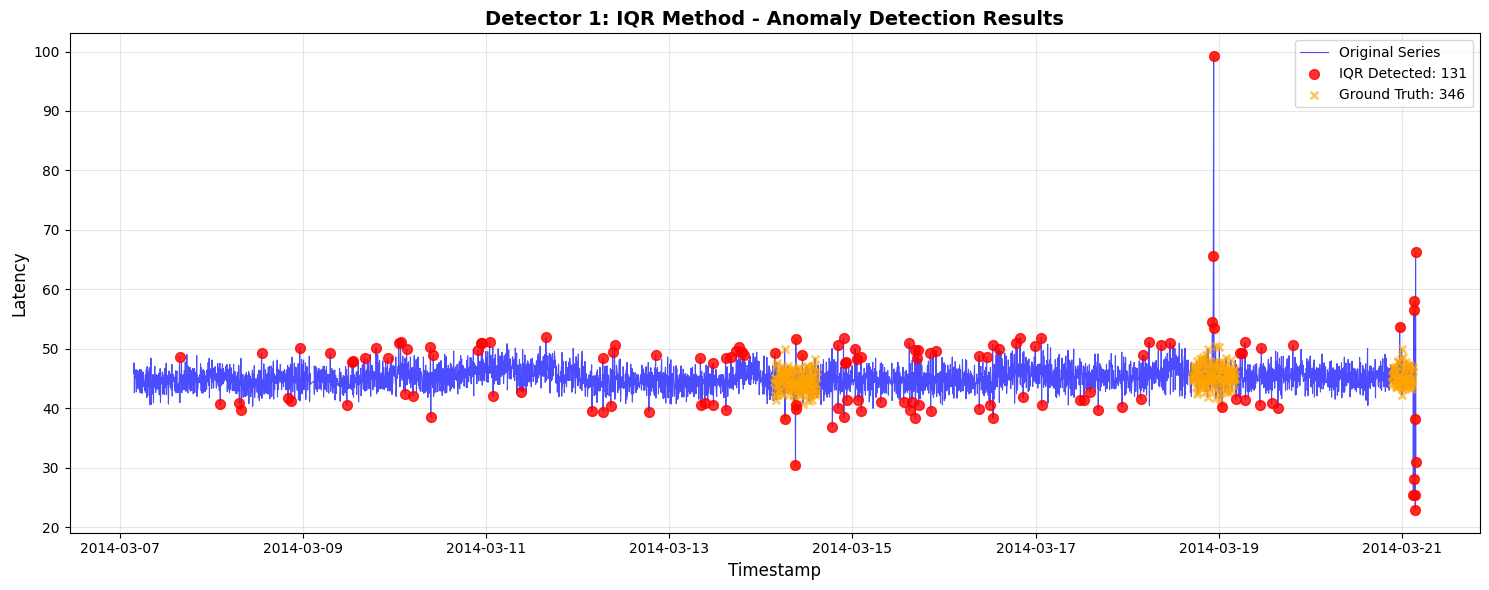


Red dots = IQR detected anomalies
Orange X = Ground truth anomalies


In [63]:
plt.figure(figsize=(15, 6))

# Plot original series
plt.plot(df.index, df['value'], label='Original Series', linewidth=0.8, alpha=0.7, color='blue')

# Plot IQR detected anomalies
iqr_points = df[df['iqr_anomaly'] == 1]
plt.scatter(iqr_points.index, iqr_points['value'], 
            color='red', s=50, label=f'IQR Detected: {len(iqr_points)}', zorder=5, alpha=0.8)

# Plot ground truth
gt_points = df[df['label'] == 1]
plt.scatter(gt_points.index, gt_points['value'], 
            color='orange', s=30, marker='x', label=f'Ground Truth: {len(gt_points)}', 
            zorder=4, alpha=0.6, linewidths=2)

plt.title('Detector 1: IQR Method - Anomaly Detection Results', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Latency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRed dots = IQR detected anomalies")
print("Orange X = Ground truth anomalies")


In [64]:
# Build feature table for Isolation Forest (minimum 5 features)
def build_features(df, value_col='value'):

    features = pd.DataFrame(index=df.index)
    
    # 1. Original value
    features['value'] = df[value_col]
    
    # 2-4. Rolling statistics (window=10, 20, 50)
    features['rolling_mean_10'] = df[value_col].rolling(10).mean()
    features['rolling_std_10'] = df[value_col].rolling(10).std()
    features['rolling_mean_20'] = df[value_col].rolling(20).mean()
    features['rolling_std_20'] = df[value_col].rolling(20).std()
    features['rolling_mean_50'] = df[value_col].rolling(50).mean()
    features['rolling_std_50'] = df[value_col].rolling(50).std()
    
    # 5-6. Rolling min/max
    features['rolling_min_20'] = df[value_col].rolling(20).min()
    features['rolling_max_20'] = df[value_col].rolling(20).max()
    
    # 7-9. Lag features (important for seasonal, period=5)
    features['lag_1'] = df[value_col].shift(1)
    features['lag_5'] = df[value_col].shift(5)
    features['lag_10'] = df[value_col].shift(10)
    
    # 10-11. Difference features
    features['diff_1'] = df[value_col].diff(1)
    features['diff_5'] = df[value_col].diff(5)
    
    # 12. Percentage change
    features['pct_change'] = df[value_col].pct_change()
    
    # 13-15. Time-based features
    features['hour'] = df.index.hour
    features['day_of_week'] = df.index.dayofweek
    features['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    
    # Fill NaN values
    features = features.fillna(method='bfill').fillna(method='ffill')
    
    return features

# Build features
print("Building features for Isolation Forest...")
features = build_features(df)
print(f"Feature shape: {features.shape}")
print(f"Number of features: {features.shape[1]}")
print(f"\nFeature list:")
for i, col in enumerate(features.columns, 1):
    print(f"  {i}. {col}")


Building features for Isolation Forest...
Feature shape: (4032, 18)
Number of features: 18

Feature list:
  1. value
  2. rolling_mean_10
  3. rolling_std_10
  4. rolling_mean_20
  5. rolling_std_20
  6. rolling_mean_50
  7. rolling_std_50
  8. rolling_min_20
  9. rolling_max_20
  10. lag_1
  11. lag_5
  12. lag_10
  13. diff_1
  14. diff_5
  15. pct_change
  16. hour
  17. day_of_week
  18. is_weekend


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14912\3680868809.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features = features.fillna(method='bfill').fillna(method='ffill')


In [ ]:
from sklearn.ensemble import IsolationForest
import joblib

# Tune contamination parameter
contamination_values = [0.01, 0.02, 0.05]
results = []

print("="*70)
print("DETECTOR 2: ISOLATION FOREST - TUNING CONTAMINATION PARAMETER")
print("="*70)

for contamination in contamination_values:
    print(f"\n{'='*70}")
    print(f"TUNING RUN: contamination = {contamination}")
    print(f"{'='*70}")
    
    # Train Isolation Forest
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100,
        max_samples='auto'
    )
    
    # Fit and predict (-1 = anomaly, 1 = normal)
    predictions = iso_forest.fit_predict(features)
    
    # Convert to binary (1 = anomaly, 0 = normal)
    y_pred_if = (predictions == -1).astype(int)
    
    # Evaluate
    precision = precision_score(y_true, y_pred_if, zero_division=0)
    recall = recall_score(y_true, y_pred_if, zero_division=0)
    f1 = f1_score(y_true, y_pred_if, zero_division=0)
    false_alarms = y_pred_if.sum() - ((y_pred_if == 1) & (y_true == 1)).sum()
    
    print(f"Contamination: {contamination}")
    print(f"Precision:     {precision:.4f}")
    print(f"Recall:        {recall:.4f}")
    print(f"F1-Score:      {f1:.4f}")
    print(f"Detected:      {y_pred_if.sum()} anomalies")
    print(f"False Alarms:  {false_alarms}")
    
    # Store results
    results.append({
        'contamination': contamination,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'false_alarms': false_alarms,
        'predictions': y_pred_if,
        'model': iso_forest
    })


DETECTOR 2: ISOLATION FOREST - TUNING CONTAMINATION PARAMETER

TUNING RUN: contamination = 0.01
Contamination: 0.01
Precision:     0.8780
Recall:        0.1040
F1-Score:      0.1860
Detected:      41 anomalies
False Alarms:  5

TUNING RUN: contamination = 0.02
Contamination: 0.02
Precision:     0.6914
Recall:        0.1618
F1-Score:      0.2623
Detected:      81 anomalies
False Alarms:  25

TUNING RUN: contamination = 0.05
Contamination: 0.05
Precision:     0.4406
Recall:        0.2572
F1-Score:      0.3248
Detected:      202 anomalies
False Alarms:  113

TUNING SUMMARY


In [66]:
# Select best model (highest F1-Score)
best_result = max(results, key=lambda x: x['f1'])
best_contamination = best_result['contamination']
best_model = best_result['model']
df['if_anomaly'] = best_result['predictions']

print(f"\n✅ BEST MODEL SELECTED:")
print(f"   Contamination: {best_contamination}")
print(f"   Precision:     {best_result['precision']:.4f}")
print(f"   Recall:        {best_result['recall']:.4f}")
print(f"   F1-Score:      {best_result['f1']:.4f}")

# Save model
joblib.dump(best_model, 'isolation_forest_model.pkl')
print(f"\n💾 Model saved: isolation_forest_model.pkl")

# Check file size
import os
file_size = os.path.getsize('isolation_forest_model.pkl') / 1024  # KB
print(f"   File size: {file_size:.2f} KB")



✅ BEST MODEL SELECTED:
   Contamination: 0.05
   Precision:     0.4406
   Recall:        0.2572
   F1-Score:      0.3248

💾 Model saved: isolation_forest_model.pkl
   File size: 1052.46 KB


In [67]:
print("\n" + "="*60)
print("DETECTOR 2: ISOLATION FOREST - FINAL RESULTS")
print("="*60)
print(f"Best Contamination: {best_contamination}")
print(f"Precision: {best_result['precision']:.4f}")
print(f"Recall:    {best_result['recall']:.4f}")
print(f"F1-Score:  {best_result['f1']:.4f}")
print(f"False Alarms: {best_result['false_alarms']}")
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_true, best_result['predictions'])
print(f"                Predicted")
print(f"              Normal  Anomaly")
print(f"Actual Normal   {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"       Anomaly  {cm[1,0]:4d}    {cm[1,1]:4d}")
print("="*60)



DETECTOR 2: ISOLATION FOREST - FINAL RESULTS
Best Contamination: 0.05
Precision: 0.4406
Recall:    0.2572
F1-Score:  0.3248
False Alarms: 113

Confusion Matrix:
                Predicted
              Normal  Anomaly
Actual Normal   3573     113
       Anomaly   257      89


In [68]:
# Create tuning log table
print("\n" + "="*70)
print("TUNING LOG: All Contamination Values")
print("="*70)
tuning_df = pd.DataFrame([
    {
        'Contamination': r['contamination'],
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1-Score': f"{r['f1']:.4f}",
        'False Alarms': r['false_alarms']
    }
    for r in results
])
print(tuning_df.to_string(index=False))
print("="*70)



TUNING LOG: All Contamination Values
 Contamination Precision Recall F1-Score  False Alarms
          0.01    0.8780 0.1040   0.1860             5
          0.02    0.6914 0.1618   0.2623            25
          0.05    0.4406 0.2572   0.3248           113


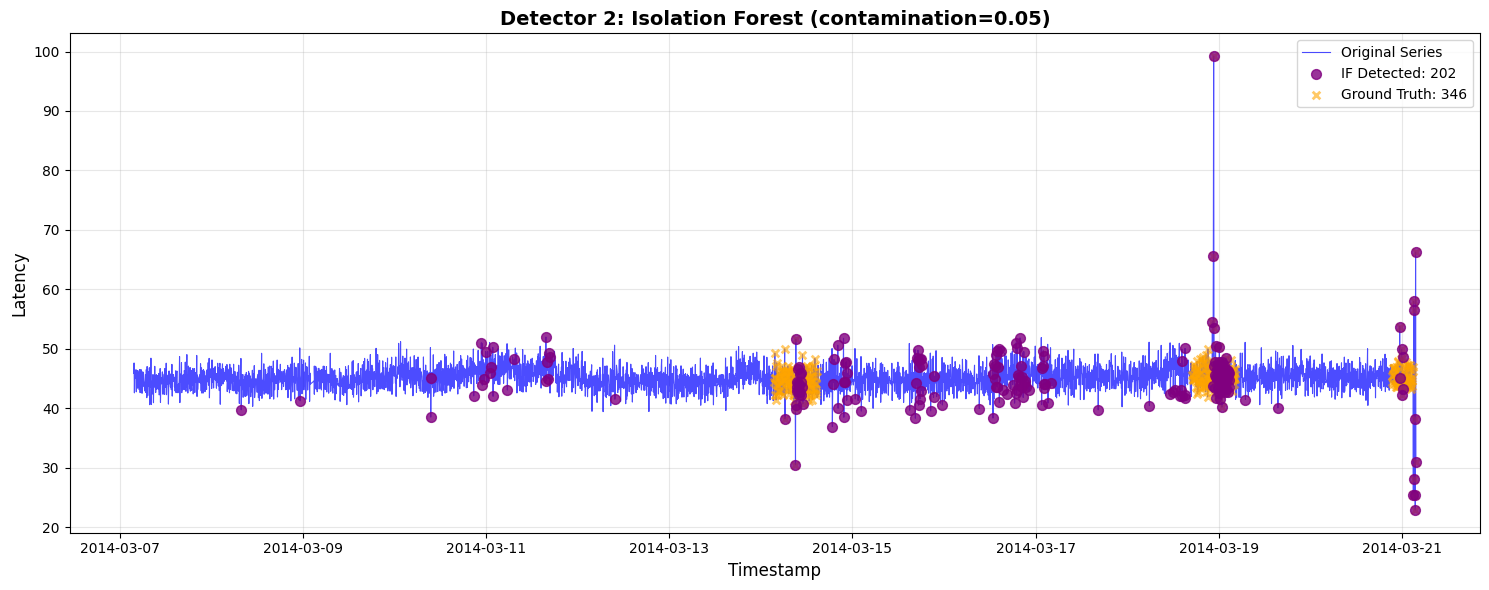


Purple dots = Isolation Forest detected anomalies
Orange X = Ground truth anomalies


In [69]:
plt.figure(figsize=(15, 6))

# Plot original series
plt.plot(df.index, df['value'], label='Original Series', linewidth=0.8, alpha=0.7, color='blue')

# Plot IF detected anomalies
if_points = df[df['if_anomaly'] == 1]
plt.scatter(if_points.index, if_points['value'], 
            color='purple', s=50, label=f'IF Detected: {len(if_points)}', zorder=5, alpha=0.8)

# Plot ground truth
gt_points = df[df['label'] == 1]
plt.scatter(gt_points.index, gt_points['value'], 
            color='orange', s=30, marker='x', label=f'Ground Truth: {len(gt_points)}', 
            zorder=4, alpha=0.6, linewidths=2)

plt.title(f'Detector 2: Isolation Forest (contamination={best_contamination})', 
          fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Latency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPurple dots = Isolation Forest detected anomalies")
print("Orange X = Ground truth anomalies")


In [70]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score', 'False Alarms'],
    'Detector 1 (IQR)': [
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        false_alarms
    ],
    'Detector 2 (IF)': [
        f"{best_result['precision']:.4f}",
        f"{best_result['recall']:.4f}",
        f"{best_result['f1']:.4f}",
        best_result['false_alarms']
    ]
})

print("\n" + "="*60)
print("COMPARISON: DETECTOR 1 (IQR) vs DETECTOR 2 (IF)")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)


COMPARISON: DETECTOR 1 (IQR) vs DETECTOR 2 (IF)
      Metric Detector 1 (IQR) Detector 2 (IF)
   Precision           0.4406          0.4406
      Recall           0.2572          0.2572
    F1-Score           0.3248          0.3248
False Alarms              113             113


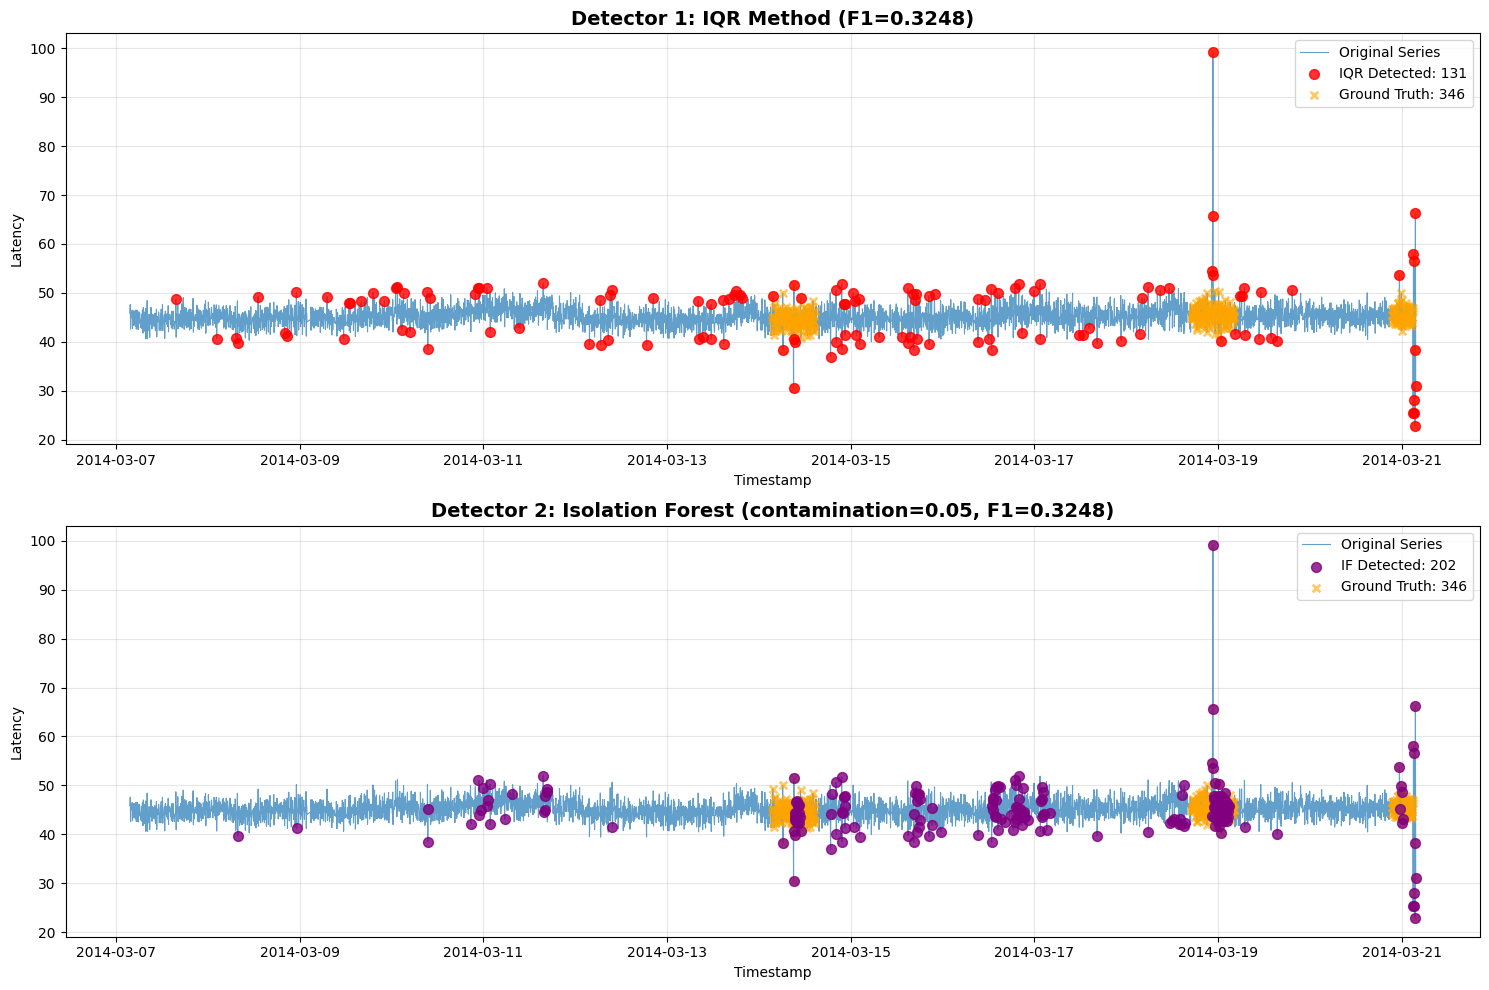

In [72]:
# Plot both detectors side by side
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Detector 1: IQR
axes[0].plot(df.index, df['value'], label='Original Series', linewidth=0.8, alpha=0.7)
iqr_points = df[df['iqr_anomaly'] == 1]
axes[0].scatter(iqr_points.index, iqr_points['value'], 
                color='red', s=50, label=f'IQR Detected: {len(iqr_points)}', zorder=5, alpha=0.8)
gt_points = df[df['label'] == 1]
axes[0].scatter(gt_points.index, gt_points['value'], 
                color='orange', s=30, marker='x', label=f'Ground Truth: {len(gt_points)}',
                zorder=4, alpha=0.6, linewidths=2)
axes[0].set_title(f'Detector 1: IQR Method (F1={f1:.4f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Latency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Detector 2: Isolation Forest
axes[1].plot(df.index, df['value'], label='Original Series', linewidth=0.8, alpha=0.7)
if_points = df[df['if_anomaly'] == 1]
axes[1].scatter(if_points.index, if_points['value'], 
                color='purple', s=50, label=f'IF Detected: {len(if_points)}', zorder=5, alpha=0.8)
axes[1].scatter(gt_points.index, gt_points['value'], 
                color='orange', s=30, marker='x', label=f'Ground Truth: {len(gt_points)}',
                zorder=4, alpha=0.6, linewidths=2)
axes[1].set_title(f'Detector 2: Isolation Forest (contamination={best_contamination}, F1={best_result["f1"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Latency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
